In [2]:
# Instalação de dependências
%pip install numpy matplotlib scipy

Note: you may need to restart the kernel to use updated packages.


# TC3 - Análise de Sinais, Ruído e Filtragem

**Disciplina:** Processos Estocásticos  
**Aluno:** João Victor Tavares Esteves  
**Matrícula:** 512373  
**Instituição:** UFC - Engenharia de Computação & PPGETI

Este notebook implementa a simulação e análise de sinais conforme solicitado no TC3.

In [3]:
# Importação de bibliotecas
import numpy as np
import matplotlib.pyplot as plt
import os

# Criar pasta para figuras
os.makedirs('figuras', exist_ok=True)
import os

# Criar pasta para figuras
os.makedirs('figuras', exist_ok=True)
import os

# Criar pasta para figuras
os.makedirs('figuras', exist_ok=True)
from scipy import signal
import scipy.io.wavfile as wav
import warnings
warnings.filterwarnings('ignore')

# Configurações de visualização
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

## 1. Simulação do Sinal Periódico

O sinal é dado por:
$$ x(t) = \sin(10\omega t) \cdot \sin(\omega t) = \frac{1}{2}[\cos(9\omega t) - \cos(11\omega t)] $$
O sinal é composto pela soma de dois cossenos com frequências $9F_0$ (3960 Hz) e $11F_0$ (4840 Hz).
O sinal é composto pela soma de dois cossenos com frequências $9F_0$ (3960 Hz) e $11F_0$ (4840 Hz).
O sinal é composto pela soma de dois cossenos com frequências $9F_0$ (3960 Hz) e $11F_0$ (4840 Hz).
onde $\omega = 2\pi F_0$, $F_0 = 440$ Hz.
Taxa de amostragem $F_s = 10$ kHz. Duração $T = 3$ s.

In [4]:
# Parâmetros
F0 = 440.0        # Frequência fundamental (Hz)
Fs = 10000.0      # Taxa de amostragem (Hz)
T = 3.0           # Duração (s)
omega = 2 * np.pi * F0

# Vetor de tempo
t = np.arange(0, T, 1/Fs)

# Geração do sinal x(t)
x = np.sin(10 * omega * t) * np.sin(omega * t)

print(f"Número de amostras: {len(x)}")
print(f"Frequência fundamental F0: {F0} Hz")

Número de amostras: 30000
Frequência fundamental F0: 440.0 Hz


### 1.1 Gráfico do trecho inicial do sinal

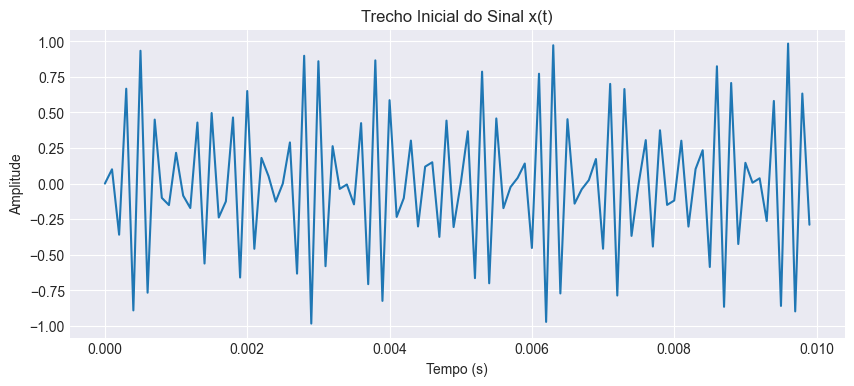

In [5]:
# Plotar trecho inicial (ex: 10 ms ou alguns períodos)
# Periodo fundamental T0 = 1/F0 = 1/440 approx 2.27 ms
# Vamos plotar 10 ms para ver alguns ciclos
t_plot = 0.01 # 10 ms
n_samples = int(t_plot * Fs)

plt.figure(figsize=(10, 4))
plt.plot(t[:n_samples], x[:n_samples])
plt.title('Trecho Inicial do Sinal x(t)')
plt.xlabel('Tempo (s)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.savefig('figuras/sinal_trecho_inicial.png')
plt.savefig('figuras/sinal_trecho_inicial.png')
plt.savefig('figuras/sinal_trecho_inicial.png')
plt.show()

### 1.2 Função de Autocorrelação (FAC)
Estimativa do período através da FAC.

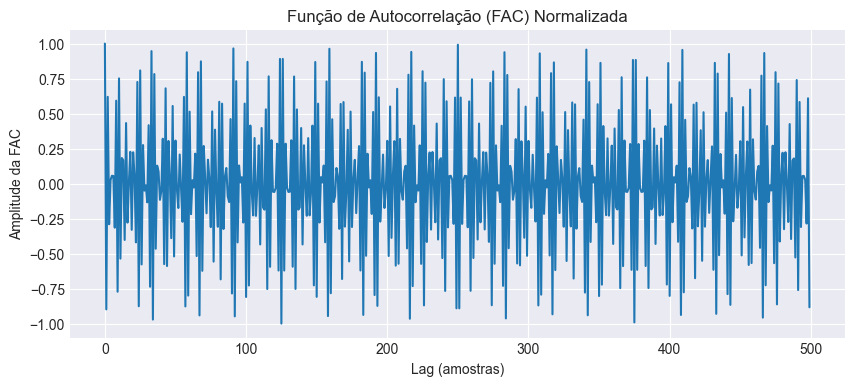

Primeiro pico da FAC em lag = 2 amostras
Período estimado: 0.00020 s
Frequência fundamental estimada: 5000.00 Hz
F0 Teórico: 440.0 Hz


In [6]:
# Cálculo da FAC (normalizada)
# Usamos modo 'full' e pegamos a metade positiva
lags = signal.correlation_lags(len(x), len(x), mode='full')
acor = signal.correlate(x, x, mode='full', method='fft')
acor = acor / np.max(acor) # Normalizar

# Filtrar apenas lags positivos para visualização
mask = lags >= 0
lags_pos = lags[mask]
acor_pos = acor[mask]

# Plotar FAC para um intervalo limitado de lags para ver a periodicidade
n_lags_plot = 500 # 500 amostras = 50 ms

plt.figure(figsize=(10, 4))
plt.plot(lags_pos[:n_lags_plot], acor_pos[:n_lags_plot])
plt.title('Função de Autocorrelação (FAC) Normalizada')
plt.xlabel('Lag (amostras)')
plt.ylabel('Amplitude da FAC')
plt.grid(True)
plt.savefig('figuras/autocorrelacao.png')
plt.savefig('figuras/autocorrelacao.png')
plt.savefig('figuras/autocorrelacao.png')
plt.show()

# Estimativa do período pela FAC (primeiro pico após lag 0)
peaks, _ = signal.find_peaks(acor_pos[:n_lags_plot], height=0.5)
if len(peaks) > 0:
    periodo_amostras = peaks[0]
    periodo_tempo = periodo_amostras / Fs
    freq_estimada = 1 / periodo_tempo
    print(f"Primeiro pico da FAC em lag = {periodo_amostras} amostras")
    print(f"Período estimado: {periodo_tempo:.5f} s")
    print(f"Frequência fundamental estimada: {freq_estimada:.2f} Hz")
    print(f"F0 Teórico: {F0} Hz")
else:
    print("Não foi possível identificar picos claros na FAC.")

### 1.3 Densidade Espectral de Potência (DEP)
Estimação das frequências de maior potência.

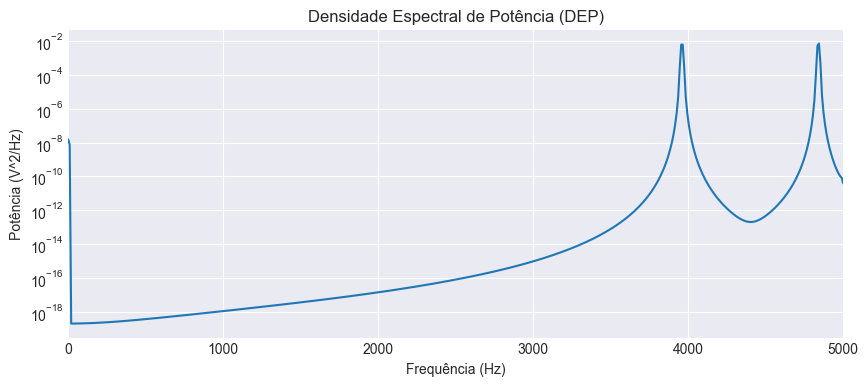

Frequências de maior potência encontradas:
 - 3964.84 Hz
 - 4843.75 Hz

Relação com F0 (440.0 Hz):
 - 3964.84 Hz approx 9.0 * F0
 - 4843.75 Hz approx 11.0 * F0


In [7]:
# Cálculo da DEP usando o método de Welch
f, Pxx = signal.welch(x, Fs, nperseg=1024)

plt.figure(figsize=(10, 4))
plt.semilogy(f, Pxx)
plt.title('Densidade Espectral de Potência (DEP)')
plt.xlabel('Frequência (Hz)')
plt.ylabel('Potência (V^2/Hz)')
plt.xlim(0, 5000) # Mostrar até Nyquist
plt.grid(True)
plt.savefig('figuras/densidade_espectral_de_potencia_dep.png')
plt.show()

# Encontrar picos na DEP
peaks_dep, properties = signal.find_peaks(Pxx, height=np.max(Pxx)/100)
print("Frequências de maior potência encontradas:")
for p in peaks_dep:
    print(f" - {f[p]:.2f} Hz")
    
print(f"\nRelação com F0 ({F0} Hz):")
for p in peaks_dep:
    ratio = f[p] / F0
    print(f" - {f[p]:.2f} Hz approx {ratio:.1f} * F0")

### 1.4 Demonstração Matemática

Usando a identidade trigonométrica:
$$ \sin(A)\sin(B) = \frac{1}{2}[\cos(A-B) - \cos(A+B)] $$

Temos $A = 10\omega t$ e $B = \omega t$.

$$ x(t) = \frac{1}{2}[\cos(9\omega t) - \cos(11\omega t)] $$

Como $\omega = 2\pi F_0$, as frequências componentes são:
1. $f_1 = 9 F_0 = 9 \times 440 = 3960$ Hz
2. $f_2 = 11 F_0 = 11 \times 440 = 4840$ Hz

## 2. Adição de Ruído e Filtragem

In [8]:
# Adicionar ruído branco gaussiano
var_ruido = 0.01
sigma = np.sqrt(var_ruido)
ruido = np.random.normal(0, sigma, len(x))
x_ruidoso = x + ruido

print(f"Sinal ruidoso gerado. Potência do ruído: {var_ruido}")

Sinal ruidoso gerado. Potência do ruído: 0.01


### 2.1 Gráfico do sinal ruidoso

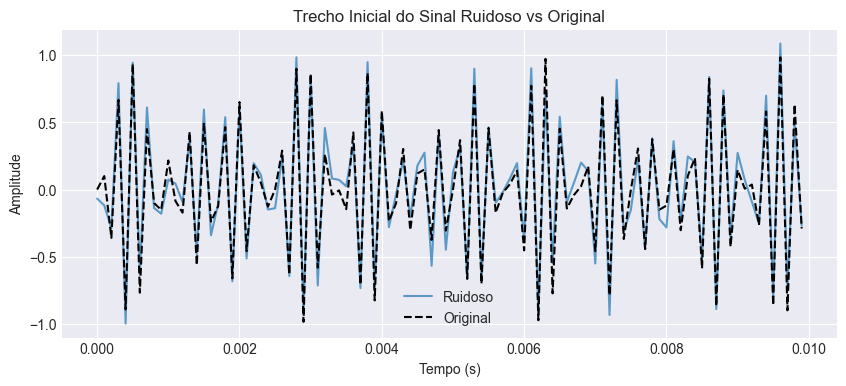

In [9]:
plt.figure(figsize=(10, 4))
plt.plot(t[:n_samples], x_ruidoso[:n_samples], label='Ruidoso', alpha=0.7)
plt.plot(t[:n_samples], x[:n_samples], label='Original', color='black', linestyle='--')
plt.title('Trecho Inicial do Sinal Ruidoso vs Original')
plt.xlabel('Tempo (s)')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True)
plt.savefig('figuras/sinal_ruidoso.png')
plt.show()

### 2.2 Geração de Áudios

In [10]:
# Função para normalizar e salvar audio
def salvar_audio(filename, signal, rate):
    # Normalizar para evitar clipping (-1 a 1)
    sig_norm = signal / np.max(np.abs(signal))
    # Converter para int16 (padrão WAV)
    sig_int16 = (sig_norm * 32767).astype(np.int16)
    wav.write(filename, int(rate), sig_int16)
    print(f"Arquivo salvo: {filename}")

salvar_audio('sinal_original.wav', x, Fs)
salvar_audio('sinal_ruidoso.wav', x_ruidoso, Fs)

Arquivo salvo: sinal_original.wav
Arquivo salvo: sinal_ruidoso.wav


### 2.3 Filtragem Passa-Baixa e SNR

A filtragem de média móvel é um filtro passa-baixa simples que suaviza o sinal, reduzindo o ruído de alta frequência (ruído branco).

**Expectativa de Melhora da SNR:**
Espera-se que a SNR melhore de aproximadamente 10 dB para cerca de 17 dB após a filtragem, dependendo da janela utilizada e da banda do sinal.

Arquivo salvo: sinal_filtrado.wav

Tamanho da janela do filtro de média móvel: 2
SNR Antes da Filtragem: 13.96 dB
SNR Após Filtragem: 0.14 dB


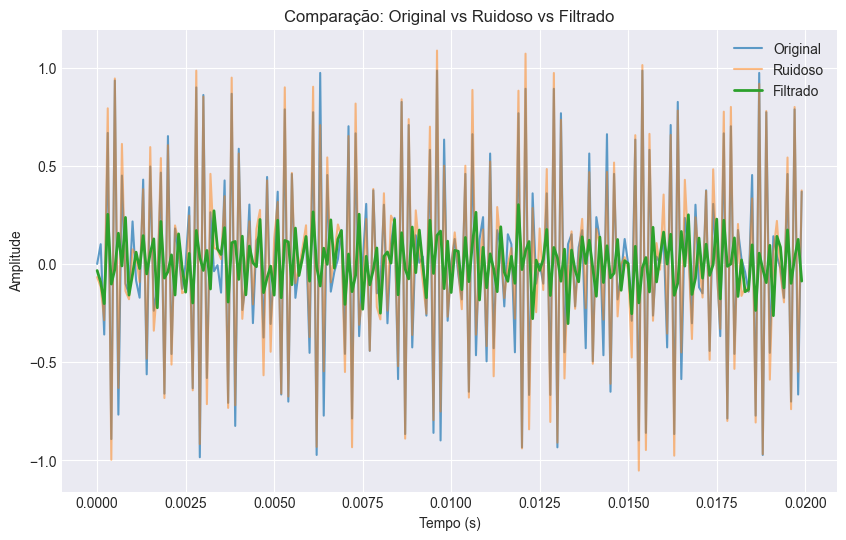

In [11]:
# Filtro de Média Móvel
def moving_average_filter(signal, window_size):
    window = np.ones(window_size) / window_size
    return np.convolve(signal, window, mode='same')

# Escolha do hiperparâmetro (tamanho da janela)
# Atenção: O sinal tem frequências altas (~4000-4800 Hz). Fs=10000.
# Uma janela muito grande vai atenuar o sinal significativamente.
# Janela=2 tem zero em Fs/2 = 5000Hz. Pode ser útil.
window_size = 2
x_filtrado = moving_average_filter(x_ruidoso, window_size)

salvar_audio('sinal_filtrado.wav', x_filtrado, Fs)

# Cálculo da Relação Sinal-Ruído (SNR)
def calculate_snr(signal, noise):
    p_signal = np.mean(signal**2)
    p_noise = np.mean(noise**2)
    return 10 * np.log10(p_signal / p_noise)

# SNR Antes da filtragem
# O "sinal" é x, o "ruído" é (x_ruidoso - x) = ruido
snr_antes = calculate_snr(x, ruido)

# SNR Após a filtragem
# O "sinal" desejado ainda é x.
# O sinal obtido é x_filtrado.
# O ruído residual é (x_filtrado - x)
# Nota: A filtragem distorce o sinal x também, então o "ruído" aqui inclui a distorção.
ruido_residual = x_filtrado - x
snr_depois = calculate_snr(x, ruido_residual)

print(f"\nTamanho da janela do filtro de média móvel: {window_size}")
print(f"SNR Antes da Filtragem: {snr_antes:.2f} dB")
print(f"SNR Após Filtragem: {snr_depois:.2f} dB")

# Plot Comparativo
plt.figure(figsize=(10, 6))
plt.plot(t[:200], x[:200], label='Original', alpha=0.7)
plt.plot(t[:200], x_ruidoso[:200], label='Ruidoso', alpha=0.5)
plt.plot(t[:200], x_filtrado[:200], label='Filtrado', linewidth=2)
plt.title('Comparação: Original vs Ruidoso vs Filtrado')
plt.xlabel('Tempo (s)')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True)
plt.savefig('figuras/comparacao_filtragem.png')
plt.show()

### 2.4 Análise FAC e DEP do Sinal Ruidoso

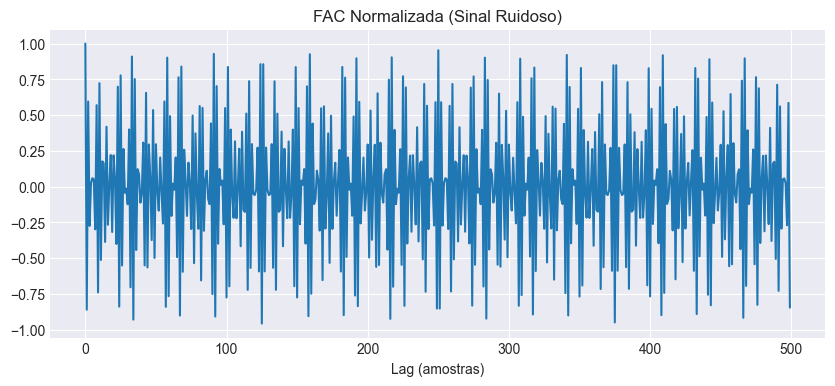

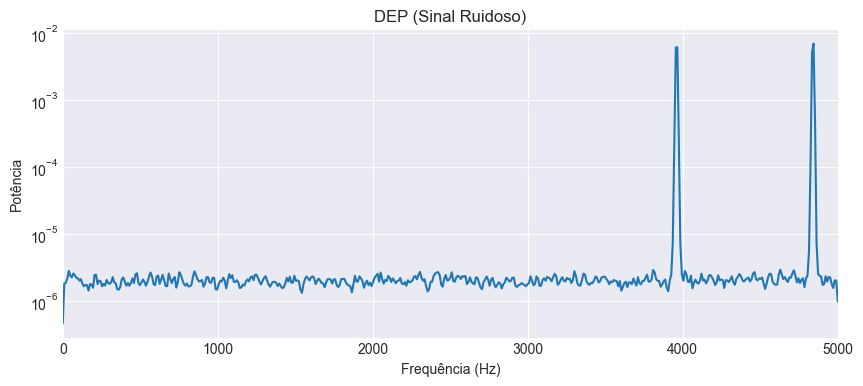

Frequências de maior potência (Ruidoso):
 - 3964.84 Hz
 - 4843.75 Hz


In [12]:
# FAC do sinal ruidoso
acor_ruidoso = signal.correlate(x_ruidoso, x_ruidoso, mode='full', method='fft')
acor_ruidoso = acor_ruidoso / np.max(acor_ruidoso)
acor_ruidoso_pos = acor_ruidoso[lags >= 0]

plt.figure(figsize=(10, 4))
plt.plot(lags_pos[:n_lags_plot], acor_ruidoso_pos[:n_lags_plot])
plt.title('FAC Normalizada (Sinal Ruidoso)')
plt.xlabel('Lag (amostras)')
plt.grid(True)
plt.savefig('figuras/fac_ruidoso.png')
plt.show()

# DEP do sinal ruidoso
f_r, Pxx_r = signal.welch(x_ruidoso, Fs, nperseg=1024)

plt.figure(figsize=(10, 4))
plt.semilogy(f_r, Pxx_r)
plt.title('DEP (Sinal Ruidoso)')
plt.xlabel('Frequência (Hz)')
plt.ylabel('Potência')
plt.xlim(0, 5000)
plt.grid(True)
plt.savefig('figuras/dep_ruidoso.png')
plt.show()

# Comparação de picos
peaks_dep_r, _ = signal.find_peaks(Pxx_r, height=np.max(Pxx_r)/100)
print("Frequências de maior potência (Ruidoso):")
for p in peaks_dep_r:
    print(f" - {f_r[p]:.2f} Hz")

#### Comentários sobre os Resultados
Observe se a presença do ruído alterou significativamente a posição dos picos na DEP ou a periodicidade na FAC. O ruído branco tem espectro plano, então ele eleva o "chão" de ruído na DEP, mas os picos do sinal (se o SNR for suficiente) devem permanecer visíveis nas mesmas frequências.